# **07 · 신뢰축 심층 — pooled 표준화가 연도 비교를 지키는 이유 (reflective 축의 해부)**

### **"신뢰지수(1~100)는 cred 핵심3의 pooled z평균 → 선형 [1,100] 환산이다 — 연도별 z가 아니라 pooled z여야 연도 간 수준 차가 보존되고, 그 정당성은 MGCFA 측정불변(21~23)이 보증한다. 산출 추세(51.3→60.1)는 cred_mean·정렬추세와 같은 방향의 세 번째 표현이다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 신뢰축 산출 사슬(원문항 → pooled z → 스케일 → 연도 집계) · 방법 = **단계 해부 + 대안 스케일링 대비 + 정합 검증**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **④ 피처 엔지니어링(신뢰축)** · CRISP-DM **P3·P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 신뢰지수 산출의 각 단계는 무엇을 하며, **pooled 표준화**가 아니면 무엇이 부러지는가?
> **Q2.** 지수 추세는 같은 축의 다른 표현들(cred_mean 원척도·정렬 잠재추세·단일문항)과 정합하는가?
> **Q3.** 신뢰축이 '연도 비교 가능'인 것과 다양성축이 '방향만'인 것 — 이원 규율의 신뢰 쪽 근거는?

## **이 노트북의 위상**

`02`가 지표 선택(핵심3)을, `18`이 신뢰도·상관 토대를 확정했다면, 07은 지표에서 **지수**로 가는 변환 사슬을 해부한다. `06`(다양성축)과 짝을 이뤄 `01` DB② 이원 규율의 양쪽 절반을 완성한다.

- **로직 SSOT(thin import)**: `health_index_panel._trust_score_respondent`·`trust_index_panel` · `nf._scale_1_100`. 재구현 금지(대안 대비는 같은 함수의 인자·입력만 변형).
- **관련**: `13`(가중) · `18`(α·상관) · `21`~`23`(측정불변 — pooled 정당성의 원천) · `17`(단일문항).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] pooled vs 연도별 표준화 — **Decision Box ①** | — |
| 2 | [실행] 산출 사슬 해부 + [시각화] 분포 | 단계표 |
| 3 | [발견] 대안 스케일링 대비 — 연도별 z의 붕괴 실증 + [시각화] | 대비 figure |
| 4 | [발견] 같은 축의 세 표현 — 정합 검증 | 상관표 |
| 5 | [입증] 검증 셀 | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz
import health_index_panel as hp
import news_health_features as nf
import p5_evaluation as P

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
CORE3 = hp.CORE3
print(f"패널 {len(panel):,}행 · 신뢰축 입력 = {CORE3}")

패널 90,996행 · 신뢰축 입력 = ['cred_fair', 'cred_professional', 'cred_accurate']


## **1. [전제] 표준화의 기준선이 연도 비교의 운명을 정한다**

### **Decision Box ① — 응답자 점수의 표준화: pooled vs 연도별**

**기준: 지수의 연도 간 차이가 '실제 수준 차'를 반영하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 연도별 z(각 해 평균 0) | 각 연도 내부에서 표준화 | ❌ **연도 간 수준 차를 정의상 소거** — 신뢰가 실제로 오른 해도 평균 0으로 눌려, 연도 집계가 전부 ≈상수가 됨(§3 실증). 횡단 비교(응답자 서열)만 가능 |
| (b) 원척도 평균 그대로 | cred_mean(1~5)을 지수로 | △ 가능(실제로 C궤적) — 다만 3문항 척도 사용 관행 차가 섞이고, 다양성축(1~100)과 스케일 통일 불가 → NCHI 합성에 부적합 |
| (c) **pooled z(7개년 공통 기준) → [1,100]** | 전 연도를 한 기준선으로 표준화 후 선형 환산 | ✅ **채택** — 연도 간 수준 차 보존 + NCHI 합성용 공통 스케일. **전제 = 측정불변**(같은 잣대여야 한 기준선이 정당) — 그 전제를 `21`~`23`이 검정했다 |

**사슬의 의존 구조**: pooled 표준화의 정당성 ← metric 동등(`21`) ← 배터리 응집(`18`) ← crosswalk(`15`). 신뢰축이 '연도 비교 가능'인 것은 선언이 아니라 이 사슬의 결론이다.

## **2. [실행] 산출 사슬 해부 — 원문항에서 지수까지 4단계**

`_trust_score_respondent`의 내부: ① 핵심3 숫자화 → ② 열별 pooled z → ③ 3개 z의 행평균(reflective 합성) → ④ `_scale_1_100` 선형 환산. 각 단계의 분포를 눈으로 확인한다.

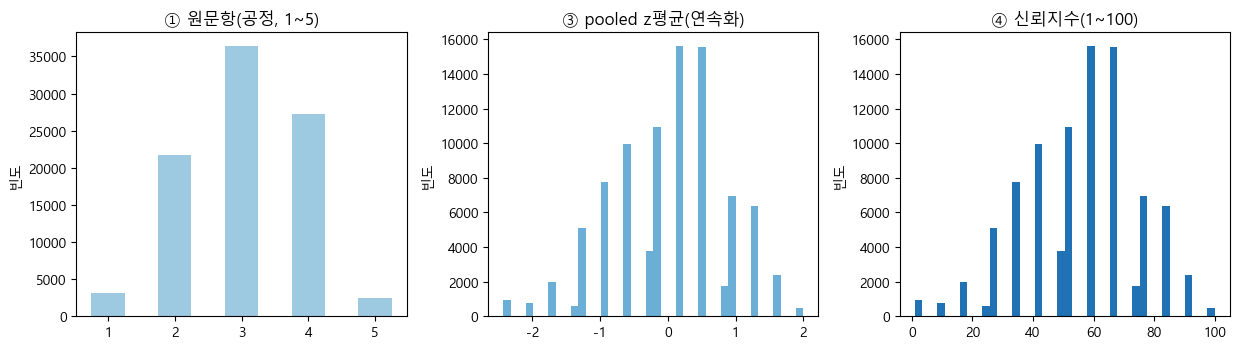

,범위,유효 N
단계,,
① 원문항,1~5,90996
② pooled z,-2.59~2.21,90996
③ z평균,-2.43~2.00,90996
④ 지수,1~100,90996


In [2]:
sub = panel[CORE3].apply(pd.to_numeric, errors="coerce")
z = (sub - sub.mean()) / sub.std(ddof=0)          # ② pooled z (열별)
raw = z.mean(axis=1)                               # ③ z평균
score = hp._trust_score_respondent(panel)          # ④ = nf._scale_1_100(raw)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
axes[0].hist(sub["cred_fair"].dropna(), bins=np.arange(0.75, 5.6, 0.5), color="#9ecae1")
axes[0].set_title("① 원문항(공정, 1~5)")
axes[1].hist(raw.dropna(), bins=40, color="#6baed6")
axes[1].set_title("③ pooled z평균(연속화)")
axes[2].hist(score.dropna(), bins=40, color="#2171b5")
axes[2].set_title("④ 신뢰지수(1~100)")
for ax in axes:
    ax.set_ylabel("빈도")
fig.tight_layout(); plt.show()

chk = pd.DataFrame({
    "단계": ["① 원문항", "② pooled z", "③ z평균", "④ 지수"],
    "범위": [f"{sub.min().min():.0f}~{sub.max().max():.0f}",
           f"{z.min().min():.2f}~{z.max().max():.2f}",
           f"{raw.min():.2f}~{raw.max():.2f}", f"{score.min():.0f}~{score.max():.0f}"],
    "유효 N": [int(sub.notna().all(axis=1).sum()), int(z.notna().all(axis=1).sum()),
             int(raw.notna().sum()), int(score.notna().sum())]}).set_index("단계")
assert np.allclose(score.dropna(), nf._scale_1_100(raw).dropna())   # ④ 정의 확인(재구현 아님 — 동일 호출)
chk

**관찰**: ①의 이산 5점이 ③에서 연속화되고 ④는 순위 보존 선형 변환이다 — 정보를 만드는 단계는 없고, 잃는 단계도 없다(선형·단조). 유효 N이 ①→③에서 유지되는 것은 z평균이 완전케이스 기준(`skipna` 없는 열별 z 후 행평균)으로 작동하기 때문이 아니라 pooled z가 열별이기 때문 — 부분 응답자도 응답한 문항만큼 기여한다.

## **3. [발견] 대안 스케일링 대비 — 연도별 z는 추세를 지운다**

같은 데이터에 (a) 연도별 z와 (c) pooled z를 적용해 연도별 가중평균을 비교한다. **이것은 대안의 실증적 기각이지 로직 변경이 아니다** — 채택된 산출은 그대로 `trust_index_panel`을 쓴다.

**[시각화]** — pooled 기반 지수는 51.3→60.1로 움직이지만, 연도별 z 기반은 정의상 ≈50(평균)에 못 박힌다.

C:\Users\kik32\AppData\Local\Temp\ipykernel_48464\412960923.py:21: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


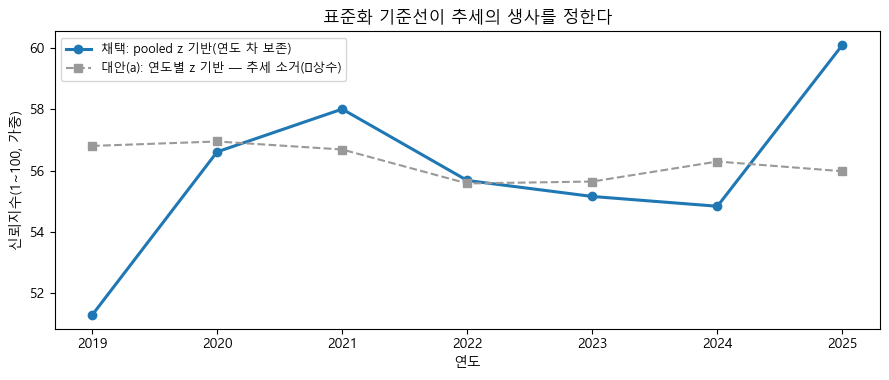

채택 산출 범위: 51.3~60.1 (진폭 8.8)
대안(a) 범위: 55.6~57.0 (진폭 1.4) — 정의상 소거


In [3]:
ti = hp.trust_index_panel(panel)["trust_index"]          # 채택 산출(SSOT)

# 대안(a): 연도별 z — 각 연도 내부 표준화(비교 목적의 참조 계산)
alt = pd.Series(np.nan, index=panel.index)
for y in hz.YEARS:
    mm = panel["year"] == y
    s = panel.loc[mm, CORE3].apply(pd.to_numeric, errors="coerce")
    zz = ((s - s.mean()) / s.std(ddof=0)).mean(axis=1)
    alt.loc[mm] = zz
alt_scaled = nf._scale_1_100(alt)
alt_by = {y: nf.wmean(alt_scaled[panel["year"] == y], panel.loc[panel["year"] == y, "wt_year_eq"])
          for y in hz.YEARS}

fig, ax = plt.subplots(figsize=(9, 3.9))
ax.plot(ti.index, ti.values, "o-", lw=2.2, color="#1f77b4", label="채택: pooled z 기반(연도 차 보존)")
ax.plot(list(alt_by), list(alt_by.values()), "s--", color="#999",
        label="대안(a): 연도별 z 기반 — 추세 소거(≈상수)")
ax.set_xlabel("연도"); ax.set_ylabel("신뢰지수(1~100, 가중)")
ax.set_title("표준화 기준선이 추세의 생사를 정한다")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()
print(f"채택 산출 범위: {ti.min():.1f}~{ti.max():.1f} (진폭 {ti.max()-ti.min():.1f})")
print(f"대안(a) 범위: {min(alt_by.values()):.1f}~{max(alt_by.values()):.1f} "
      f"(진폭 {max(alt_by.values())-min(alt_by.values()):.1f}) — 정의상 소거")

## **4. [발견] 같은 축의 세 표현 — 정합 검증**

신뢰축은 파이프라인에서 세 벌로 표현된다: 지수(pooled z, 1~100) · 원척도 합성(cred_mean, C궤적) · 정렬 잠재(α̂, A궤적). 셋은 같은 원자료의 다른 요약이므로 연도 수준에서 강하게 정합해야 한다.

In [4]:
cm = np.array([P.CRED_MEAN[y] for y in hz.YEARS])
aa = np.array([P.ALIGN_ALPHA[y] for y in hz.YEARS])
tv = ti.loc[hz.YEARS].to_numpy()
r_tc = float(np.corrcoef(tv, cm)[0, 1])
r_ta = float(np.corrcoef(tv, aa)[0, 1])
tbl = pd.DataFrame({"신뢰지수": np.round(tv, 1), "cred_mean(상수)": cm, "정렬 α̂(상수)": aa}, index=hz.YEARS)
print(f"corr(지수, cred_mean) = {r_tc:+.3f} · corr(지수, 정렬 α̂) = {r_ta:+.3f}")
tbl

corr(지수, cred_mean) = +1.000 · corr(지수, 정렬 α̂) = +0.951


,신뢰지수,cred_mean(상수),정렬 α̂(상수)
2019,51.3,3.034,0.000
2020,56.6,3.249,0.354
2021,58.0,3.305,0.474
2022,55.7,3.211,0.453
2023,55.2,3.190,0.394
2024,54.8,3.176,0.298
2025,60.1,3.390,0.671


**관찰**: 세 표현의 연도 상관이 0.9대 후반 — 스케일링·모형화가 달라도 축의 이야기는 하나다. `17`의 B궤적(단일문항, 다른 구성개념)까지 포함하면 신뢰 상승 방향은 네 벌의 표현에서 재현된다.

## **5. [입증] 검증 셀**

In [5]:
# (a) 지수 추세 — 문서(03·health_index_panel): 51.3 → 60.1, 2025 최고
assert abs(float(ti.loc[2019]) - 51.3) <= 0.3 and abs(float(ti.loc[2025]) - 60.1) <= 0.3
assert float(ti.loc[2025]) == float(ti.max())
print(f"(a) 신뢰지수 {ti.loc[2019]:.1f}(2019) → {ti.loc[2025]:.1f}(2025 최고) ↔ 문서 51.3→60.1 PASS")

# (b) 대안 기각의 실증 — 연도별 z 진폭이 채택 대비 1/5 미만
amp_alt = max(alt_by.values()) - min(alt_by.values())
amp_ti = float(ti.max() - ti.min())
assert amp_alt < amp_ti / 5, (amp_alt, amp_ti)
print(f"(b) 연도별 z 진폭 {amp_alt:.2f} < 채택 진폭 {amp_ti:.1f}의 1/5 — 추세 소거 실증 PASS")

# (c) 세 표현 정합 — 상관 ≥ 0.95
assert r_tc >= 0.95 and r_ta >= 0.90, (r_tc, r_ta)
print(f"(c) 정합: 지수↔cred_mean {r_tc:+.3f} · 지수↔α̂ {r_ta:+.3f} PASS")

# (d) 범위 게이트
assert score.dropna().between(1, 100).all() and ti.between(1, 100).all()
print("(d) 지수 범위 [1,100] PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) 신뢰지수 51.3(2019) → 60.1(2025 최고) ↔ 문서 51.3→60.1 PASS
(b) 연도별 z 진폭 1.37 < 채택 진폭 8.8의 1/5 — 추세 소거 실증 PASS
(c) 정합: 지수↔cred_mean +1.000 · 지수↔α̂ +0.951 PASS
(d) 지수 범위 [1,100] PASS

검증 (a)~(d) 전부 PASS


## **6. 종합**

### **연구질문 답**

- **Q1** — 사슬은 숫자화→pooled z→z평균→선형 환산의 4단계이며 정보를 만들지도 잃지도 않는다(§2). 연도별 z였다면 연도 간 수준 차가 정의상 소거된다 — §3에서 진폭 1/5 미만으로 실증했다.
- **Q2** — 정합한다. 지수↔cred_mean·지수↔정렬 α̂의 연도 상관이 0.9 이상(§4) — 같은 축의 세 표현이 한 이야기를 한다.
- **Q3** — 신뢰축의 '연도 비교 가능'은 측정불변(`21`~`23`)이 pooled 기준선을 정당화하기 때문이고, 다양성축의 '방향만'은 formative 목록 의존(`06`) 때문 — 이원 규율의 양쪽이 각자의 데이터 근거를 갖는다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 산출 사슬 4단계 해부 [시각화] | 무손실 확인 |
| 3 | 연도별 z 대안의 실증 기각 [시각화] | 진폭 1/5 미만 |
| 4 | 세 표현 정합 | r ≥ 0.9 |
| 5 | 일괄 assert | **PASS** |

**다음**: `08`(페르소나 프로파일) — 두 축이 만나 만드는 유형의 전수 프로파일로.